In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [35]:
 #LOAD DATASET
# Upload creditcard.csv to Colab before running this cell.
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# CELL 3: BASIC DATA INFORMATION

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 284807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 no

In [4]:
# CELL 4: CHECK TARGET VARIABLE

print("Fraud distribution:")
print(df["Class"].value_counts())

print("\nFraud percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Fraud distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


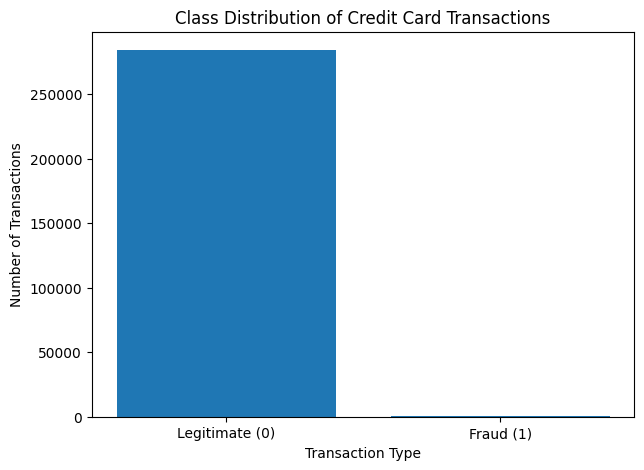

In [5]:

# CELL 5: VISUALIZE CLASS IMBALANCE

fraud_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Legitimate (0)", "Fraud (1)"],
    fraud_counts.reindex([0, 1]).values
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution of Credit Card Transactions")
plt.show()

In [6]:
# CELL 6: CHECK MISSING VALUES

missing_values = df.isnull().sum().sort_values(ascending=False)

print("Top columns with missing values:")
display(missing_values.head(20))

Top columns with missing values:


Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
dtype: int64

In [7]:
# CELL 7: SELECT FEATURES

# ULB dataset contains Time, V1-V28, Amount, and Class.
# Class is the target variable and is not included in X.
features = [
    "Time",
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15",
    "V16", "V17", "V18", "V19", "V20",
    "V21", "V22", "V23", "V24", "V25",
    "V26", "V27", "V28",
    "Amount"
]

missing_features = [
    feature for feature in features
    if feature not in df.columns
]

print("Missing selected features:", missing_features)

if not missing_features:
    print("All selected features are available.")

Missing selected features: []
All selected features are available.


In [8]:
# ============================================================
# CELL 8: CREATE X AND y
# ============================================================

X = df[features].copy()
y = df["Class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (284807, 30)
y shape: (284807,)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [9]:
# ============================================================
# CELL 9: CONVERT FEATURES TO NUMERIC
# ============================================================

for column in features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

print("Features converted to numeric.")

Features converted to numeric.


In [10]:
# ============================================================
# CELL 10: HANDLE MISSING VALUES
# ============================================================

print("Missing values before filling:")
print(X.isnull().sum().sum())

# Fill missing numeric values with the median of each feature.
X = X.fillna(X.median())

print("\nMissing values after filling:")
print(X.isnull().sum().sum())

Missing values before filling:
0

Missing values after filling:
0


In [11]:
# ============================================================
# CELL 11: CHECK FOR INFINITE VALUES
# ============================================================

infinite_count = np.isinf(X.to_numpy()).sum()
print("Infinite values before cleaning:", infinite_count)

# Replace infinite values with NaN and fill them with medians.
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Missing values after final cleaning:", X.isnull().sum().sum())
print("Infinite values after final cleaning:", np.isinf(X.to_numpy()).sum())

Infinite values before cleaning: 0
Missing values after final cleaning: 0
Infinite values after final cleaning: 0


In [12]:
# ============================================================
# CELL 12: TRAIN / TEST SPLIT
# ============================================================

# The ULB dataset is extremely imbalanced, so stratify=y keeps
# approximately the same fraud proportion in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 227845
Testing samples: 56962

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 13: CALCULATE CLASS IMBALANCE RATIO
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate transactions:", negative_count)
print("Fraudulent transactions:", positive_count)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate transactions: 227451
Fraudulent transactions: 394
Scale Pos Weight: 577.2868020304569


In [14]:
# ============================================================
# CELL 14: CREATE XGBOOST MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [15]:
# ============================================================
# CELL 15: TRAIN XGBOOST MODEL
# ============================================================

print("Training model...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Model training completed!")

Training model...
Model training completed!


In [16]:
# ============================================================
# CELL 16: PREDICT FRAUD PROBABILITY
# ============================================================

y_probability = model.predict_proba(X_test)[:, 1]

print("Prediction completed!")
print("\nFirst 20 fraud probabilities:")
print(y_probability[:20])

Prediction completed!

First 20 fraud probabilities:
[5.6429753e-06 8.6087766e-06 2.7234761e-05 3.8192397e-06 1.1578343e-03
 6.8853319e-06 4.4292146e-06 1.1304667e-05 2.2055285e-05 8.2572988e-06
 1.4827668e-04 9.9072109e-05 2.0591329e-05 9.9184608e-06 3.8037029e-05
 4.5810266e-06 5.0970550e-05 9.6755721e-06 3.5627293e-06 6.3104252e-04]


In [17]:
# ============================================================
# CELL 17: ROC-AUC SCORE
# ============================================================

roc_auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9755727593513488


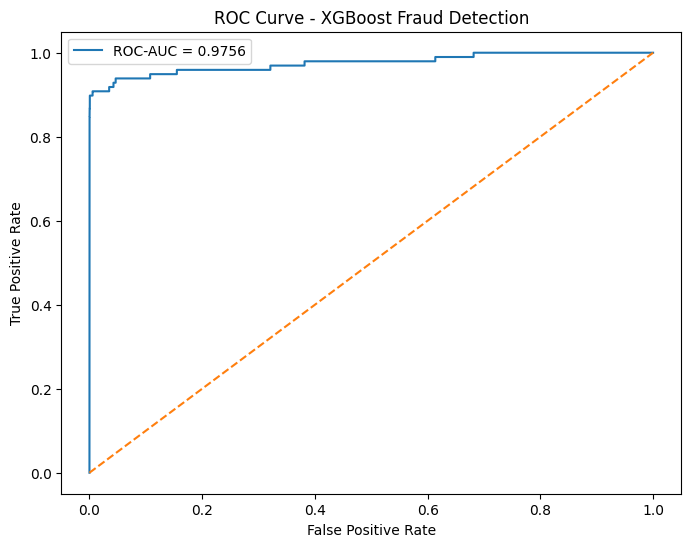

In [18]:
# ============================================================
# CELL 18: ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Fraud Detection")
plt.legend()
plt.show()

In [19]:
# ============================================================
# CELL 19: PR-AUC SCORE
# ============================================================

pr_auc = average_precision_score(y_test, y_probability)
print("PR-AUC Score:", pr_auc)

PR-AUC Score: 0.8809504553501896


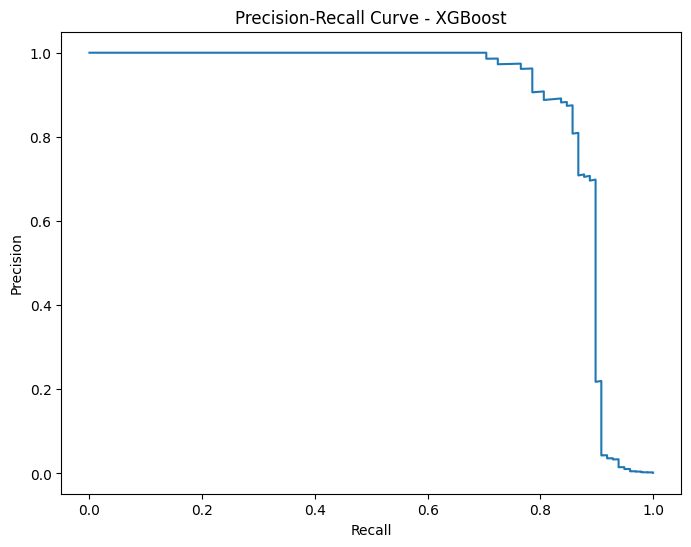

In [20]:
# ============================================================
# CELL 20: PRECISION-RECALL CURVE
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

In [21]:
# ============================================================
# CELL 21: PREDICTION USING THRESHOLD 0.5
# ============================================================

threshold = 0.5

y_pred = (y_probability >= threshold).astype(int)

print("Threshold:", threshold)
print("\nFirst 20 predicted classes:")
print(y_pred[:20])

Threshold: 0.5

First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [22]:
# ============================================================
# CELL 22: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56854    10]
 [   16    82]]


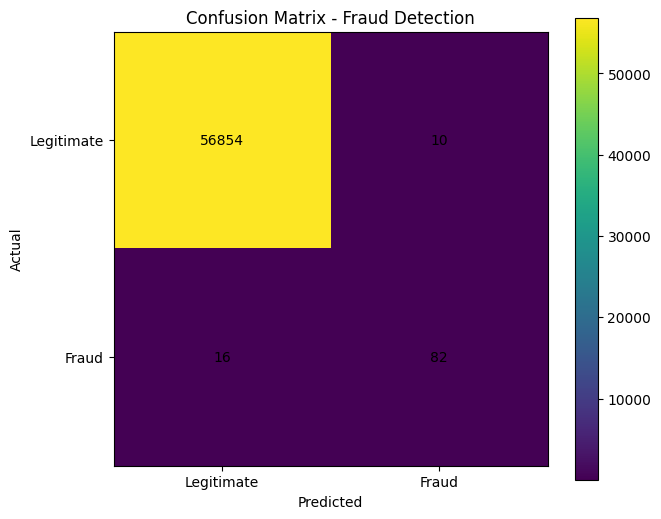

In [23]:
# ============================================================
# CELL 23: DISPLAY CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix - Fraud Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.yticks([0, 1], ["Legitimate", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [24]:
# ============================================================
# CELL 24: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
# ============================================================
# CELL 25: PRECISION, RECALL AND F1 SCORE
# ============================================================

precision_score_value = precision_score(
    y_test, y_pred, zero_division=0
)

recall_score_value = recall_score(
    y_test, y_pred, zero_division=0
)

f1_score_value = f1_score(
    y_test, y_pred, zero_division=0
)

print("Precision:", precision_score_value)
print("Recall:", recall_score_value)
print("F1 Score:", f1_score_value)

Precision: 0.8913043478260869
Recall: 0.8367346938775511
F1 Score: 0.8631578947368421


In [26]:
# ============================================================
# CELL 26: GET TN, FP, FN, TP
# ============================================================

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56854
False Positives: 10
False Negatives: 16
True Positives  : 82


In [27]:
# ============================================================
# CELL 27: FALSE POSITIVE VS FALSE NEGATIVE ANALYSIS
# ============================================================

print("FALSE POSITIVE:")
print("Legitimate transaction predicted as fraud.")
print("\nPossible consequences:")
print("- Genuine transaction may be declined")
print("- Customer inconvenience")
print("- Additional manual investigation")
print("- Possible unnecessary account restrictions")

print("\n--------------------------------------\n")

print("FALSE NEGATIVE:")
print("Fraudulent transaction predicted as legitimate.")
print("\nPossible consequences:")
print("- Fraudulent transaction may go through")
print("- Financial loss")
print("- Additional investigation and recovery costs")
print("- Potential loss of customer trust")

FALSE POSITIVE:
Legitimate transaction predicted as fraud.

Possible consequences:
- Genuine transaction may be declined
- Customer inconvenience
- Additional manual investigation
- Possible unnecessary account restrictions

--------------------------------------

FALSE NEGATIVE:
Fraudulent transaction predicted as legitimate.

Possible consequences:
- Fraudulent transaction may go through
- Financial loss
- Additional investigation and recovery costs
- Potential loss of customer trust


In [28]:
# ============================================================
# CELL 28: THRESHOLD ANALYSIS
# ============================================================

thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
results = []

for threshold in thresholds_to_test:
    predictions = (y_probability >= threshold).astype(int)

    precision_value = precision_score(
        y_test, predictions, zero_division=0
    )
    recall_value = recall_score(
        y_test, predictions, zero_division=0
    )
    f1_value = f1_score(
        y_test, predictions, zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1 Score": f1_value
    })

threshold_df = pd.DataFrame(results)
display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.1,0.642336,0.897959,0.748936
1,0.2,0.726496,0.867347,0.790698
2,0.3,0.801887,0.867347,0.833333
3,0.4,0.865979,0.857143,0.861538
4,0.5,0.891304,0.836735,0.863158
5,0.6,0.891304,0.836735,0.863158
6,0.7,0.890110,0.826531,0.857143


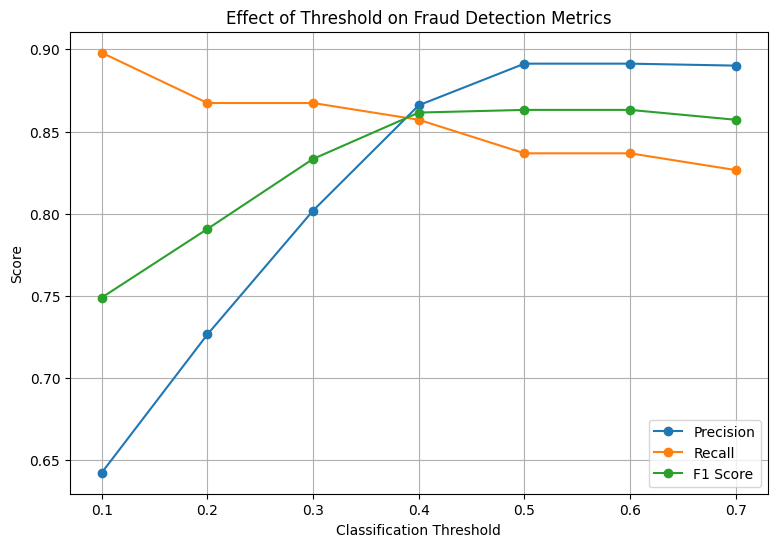

In [29]:
# ============================================================
# CELL 29: PLOT THRESHOLD PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Effect of Threshold on Fraud Detection Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# ============================================================
# CELL 30: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature importance:")
display(feature_importance)

Feature importance:


,Feature,Importance
14,V14,0.457833
10,V10,0.064578
4,V4,0.058087
12,V12,0.052554
20,V20,0.030411
8,V8,0.026264
29,Amount,0.022918
13,V13,0.021159
19,V19,0.018957
7,V7,0.018459


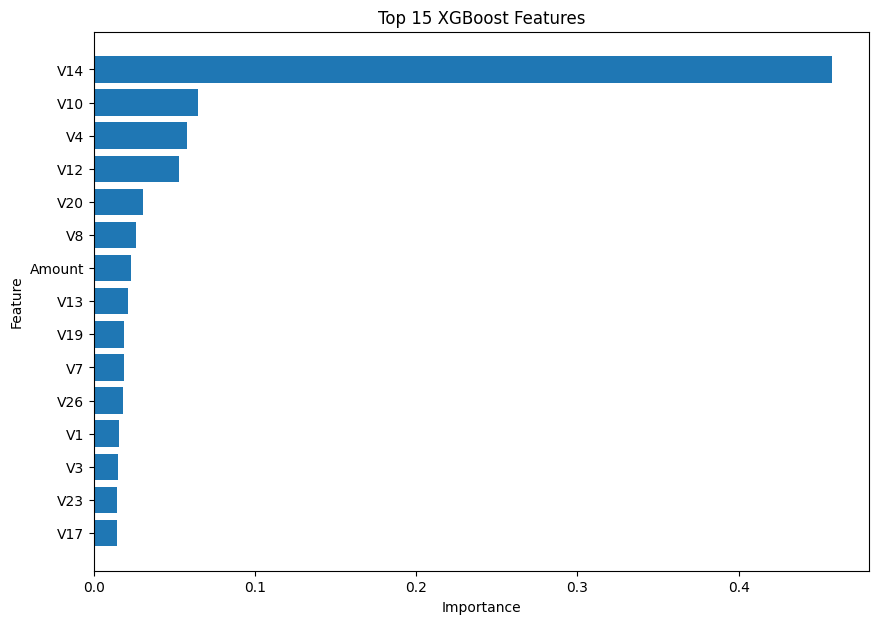

In [31]:
# ============================================================
# CELL 31: TOP 15 FEATURE IMPORTANCE PLOT
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")
plt.show()

In [32]:
# ============================================================
# CELL 32: FINAL RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print(f"Precision: {precision_score_value:.4f}")
print(f"Recall   : {recall_score_value:.4f}")
print(f"F1 Score : {f1_score_value:.4f}")

print("\nConfusion Matrix:")
print(cm)
print("\n" + "=" * 60)

FINAL MODEL RESULTS
ROC-AUC : 0.9756
PR-AUC  : 0.8810
Precision: 0.8913
Recall   : 0.8367
F1 Score : 0.8632

Confusion Matrix:
[[56854    10]
 [   16    82]]



In [33]:
# ============================================================
# CELL 33: CONCLUSION
# ============================================================

print("""
CONCLUSION:

An XGBoost classifier was developed to detect fraudulent
transactions in the Kaggle Credit Card Fraud Detection (ULB)
dataset.

Because the dataset is highly imbalanced, class weighting
using scale_pos_weight was used during model training.

The model was evaluated using ROC-AUC, PR-AUC, precision,
recall, F1-score, and a confusion matrix.

ROC-AUC measures the model's ability to distinguish
fraudulent transactions from legitimate transactions
across classification thresholds.

PR-AUC is especially useful for this highly imbalanced
fraud detection problem.

False positives represent legitimate transactions incorrectly
flagged as fraud, while false negatives represent fraudulent
transactions that were missed.

The classification threshold can therefore be adjusted
according to the relative operational cost of these errors.

Note: This is an educational machine-learning case study and
not a production fraud-detection system.
""")


CONCLUSION:

An XGBoost classifier was developed to detect fraudulent
transactions in the Kaggle Credit Card Fraud Detection (ULB)
dataset.

Because the dataset is highly imbalanced, class weighting
using scale_pos_weight was used during model training.

The model was evaluated using ROC-AUC, PR-AUC, precision,
recall, F1-score, and a confusion matrix.

ROC-AUC measures the model's ability to distinguish
fraudulent transactions from legitimate transactions
across classification thresholds.

PR-AUC is especially useful for this highly imbalanced
fraud detection problem.

False positives represent legitimate transactions incorrectly
flagged as fraud, while false negatives represent fraudulent
transactions that were missed.

The classification threshold can therefore be adjusted
according to the relative operational cost of these errors.

Note: This is an educational machine-learning case study and
not a production fraud-detection system.

